# One-class anomaly detection in retinal OCT: project walkthrough

Every stage of the pipeline, in order, run live from this notebook. Models are **not** retrained here (that took
hours on the GPU); the trained weights in `models/` are loaded and used live, and section 5 shows a short live
training run. Kernel: the project's `.venv-gpu` Python.

| Stage | Script | Section |
|---|---|---|
| Dataset check + EDA | `01_dataset_check.py`, `01b_eda.py` | 1-2 |
| Manifest + patient split | `02_build_manifest.py`, `03_split_data.py` | 3 |
| Preprocessing | `04_preprocess.py` | 4 |
| Training (M1 AE, M2 Deep SVDD, M3 VAE, M4 MKD) | `05`, `07`, `09`, `12` | 5 |
| Scoring + validation | `06`, `08`, `09`, `12`, `mid_review_val_summary.py` | 6-7 |
| Test comparison, figures, ablations | `10`, `11`, `13` | 8-9 |
| Audit | `14_audit.py` | 10 |

## 0. Setup

In [1]:
import os, sys, io, re, subprocess, time, importlib
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "config.yaml").exists() else Path.cwd().parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from IPython.display import Image as Show, Markdown, display
from PIL import Image
from common import (load_config, load_manifest, load_splits, get_split_frame, get_device, OCTDataset, CLASSES,
                    aggregate_case_scores, set_seed)
cfg = load_config(); set_seed(cfg["seed"]); device = get_device(cfg["device"])
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 9})
pd.set_option("display.width", 160)
print("project root:", ROOT)
print("device:", device, "|", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")

project root: C:\Users\Sidharth\OneDrive\Dokumen\Me llamo\University\Semester 5\ML\OCT
device: cuda | NVIDIA GeForce RTX 3050 4GB Laptop GPU


## 1. Dataset check (stage 01)

Raw dataset: *Labeled Retinal OCT Dataset for Classification of Normal, Drusen, and CNV Cases* (Noor Eye Hospital,
Mendeley Data v2), read in place from the downloaded zip. The full check report is `outputs/01_dataset_report.txt`.

In [2]:
report = (ROOT / "outputs/01_dataset_report.txt").read_text(encoding="utf-8")
print(report[report.index("## 8. Acceptance checks"):])

## 8. Acceptance checks
[PASS] cases per class = 120/160/161 -> 120/160/161
[PASS] ~16.8k images -> 16803
[PASS] NORMAL-folder abnormal labels = 29 (expect 29)
[PASS] DRUSEN/CNV-folder normal labels = 2910 (expect 2,910)
[PASS] unreadable files = 0
[CHECK] duplicate images across cases = 118


## 2. Exploratory data analysis (stage 01b)

Key findings from `outputs/eda/eda_report.md`: specialist labels differ from folder labels, abnormal slices sit in
the middle of the volume, 4 duplicated patient folders, and 7 abnormal-only patients exported in a different
layout (a shortcut a model could learn).

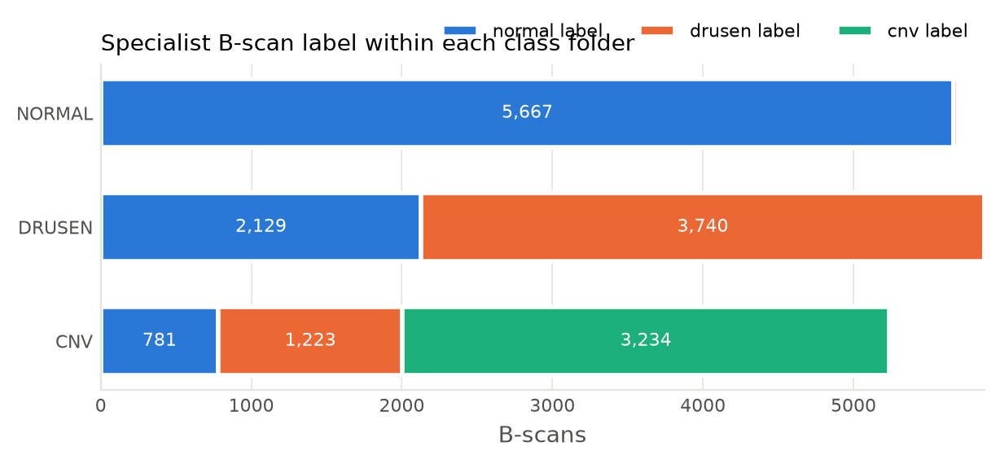

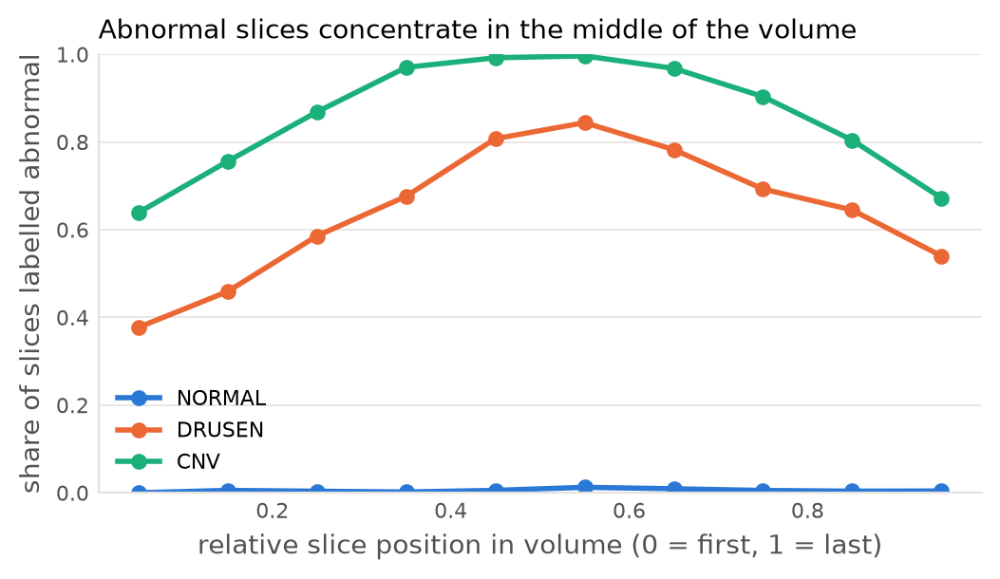

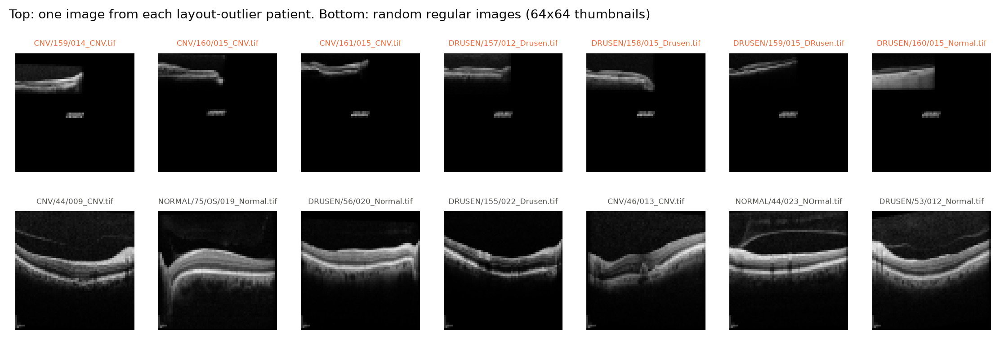

In [3]:
for f in ["01_composition.png", "03_abnormal_by_slice_position.png", "10_layout_outliers.png"]:
    display(Show(filename=str(ROOT / "outputs/eda/figures" / f), width=900))

## 3. Manifest and patient-level split (stages 02-03)

In [4]:
m, s = load_manifest(cfg), load_splits(cfg)
print(f"manifest: {len(m):,} B-scans, {m.patient_id.nunique()} patients")
display(pd.crosstab(m.class_folder, m.bscan_label, margins=True).reindex(CLASSES + ["All"]))
print("patients per class x split:")
display(pd.crosstab(s.class_folder, s.split).reindex(CLASSES))

manifest: 16,803 B-scans, 441 patients


bscan_label,cnv,drusen,normal,All
class_folder,,,,
NORMAL,0,29,5667,5696
DRUSEN,0,3740,2129,5869
CNV,3234,1223,781,5238
All,3234,4992,8577,16803


patients per class x split:


split,ablation_train,excluded,test,train,val
class_folder,,,,,
NORMAL,0,0,18,84,18
DRUSEN,32,4,84,0,40
CNV,32,3,86,0,40


In [5]:
# live leakage checks
sets = {k: set(g.patient_id) for k, g in s.groupby("split")}
overlap = [(a, b) for a in sets for b in sets if a < b and sets[a] & sets[b]]
train = get_split_frame(cfg, "train")
print("patients in two splits:", overlap or "none")
print("training pool:", len(train), "B-scans from", train.patient_id.nunique(), "patients;",
      "classes", set(train.class_folder), "| labels", set(train.bscan_label))

patients in two splits: none
training pool: 3998 B-scans from 84 patients; classes {'NORMAL'} | labels {'normal'}


## 4. Preprocessing (stage 04), live on a raw scan

The same functions as `04_preprocess.py`: mask the scale bar (rows 430-491), detect the retina (blur, Otsu, opening),
crop 352 rows centred on it, resize to 224 x 224.

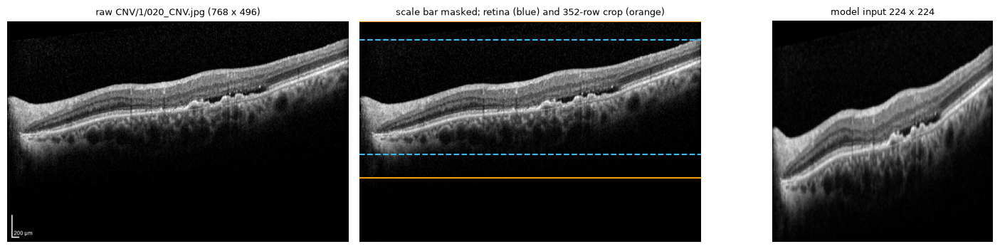

In [6]:
pre = importlib.import_module("04_preprocess")
get_ipython().run_line_magic("matplotlib", "inline")   # 04_preprocess switches matplotlib to a file backend
from common import DataSource
src = DataSource(cfg["data_root"])
rel = "CNV/1/020_CNV.jpg"                       # early in the archive, so it reads quickly
raw = np.asarray(Image.open(io.BytesIO(next(src.iter_bytes([rel]))[1])).convert("L"))
gray = raw.copy(); gray[pre.SCALE_BAR] = 0
top, bottom, cov = pre.detect_retina(gray)
out, info = pre.preprocess(raw, cfg["roi_height"], cfg["image_size"])

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].imshow(raw, cmap="gray"); ax[0].set_title(f"raw {rel} (768 x 496)")
ax[1].imshow(gray, cmap="gray")
for y, c, ls in ((top, "#38BDF8", "--"), (bottom, "#38BDF8", "--"), (info["crop_top"], "#F59E0B", "-"), (info["crop_bottom"], "#F59E0B", "-")):
    ax[1].axhline(y, color=c, ls=ls)
ax[1].set_title("scale bar masked; retina (blue) and 352-row crop (orange)")
ax[2].imshow(out, cmap="gray"); ax[2].set_title("model input 224 x 224")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

cache: 16,803 images, fallback 0.00%


class_folder
NORMAL    0.4%
DRUSEN    0.3%
CNV       1.6%
Name: retina clipped, dtype: str

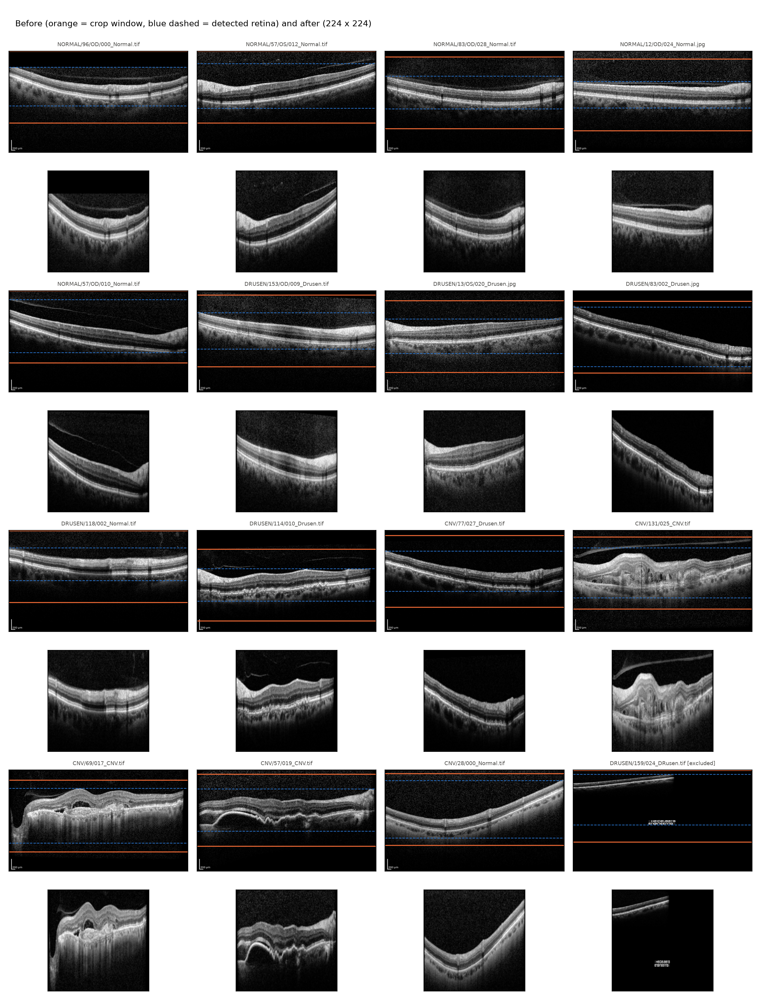

In [7]:
idx = pd.read_csv(ROOT / "outputs/cache/index.csv").merge(m[["image_path", "class_folder"]], on="image_path")
idx["clipped"] = (idx.retina_top < idx.crop_top) | (idx.retina_bottom > idx.crop_bottom)
print(f"cache: {len(idx):,} images, fallback {idx.fallback.mean():.2%}")
display(idx.groupby("class_folder").clipped.mean().reindex(CLASSES).rename("retina clipped").map("{:.1%}".format))
display(Show(filename=str(ROOT / "outputs/figures/preprocess_examples.png"), width=900))

## 5. Training (stages 05, 07, 09, 12)

All models train on the **3,998 clean-normal B-scans** of the 84 training patients only. Below: a short live run of
the autoencoder (2 epochs; it saves to `models/ae_demo.pt`, the trained model is untouched), then the real training
curves.

In [8]:
r = subprocess.run([sys.executable, "05_train_autoencoder.py", "--demo", "2"], capture_output=True, text=True)
print(r.stdout[-1500:] or r.stderr[-1500:])

device cuda | train 3998 clean-normal B-scans (84 patients) | val 819 (18 patients) | loss mse | {'lr': 0.001, 'batch_size': 32, 'max_epochs': 100, 'patience': 10}
parameters: 2,749,921
Epoch   1/2  train_loss=0.01799  val_loss=0.00414  (33.0s)  <- best so far, saved
Epoch   2/2  train_loss=0.00382  val_loss=0.00297  (28.3s)  <- best so far, saved
best val loss 0.002972 at epoch 2 -> models\ae_demo.pt
total training time 1.0 min



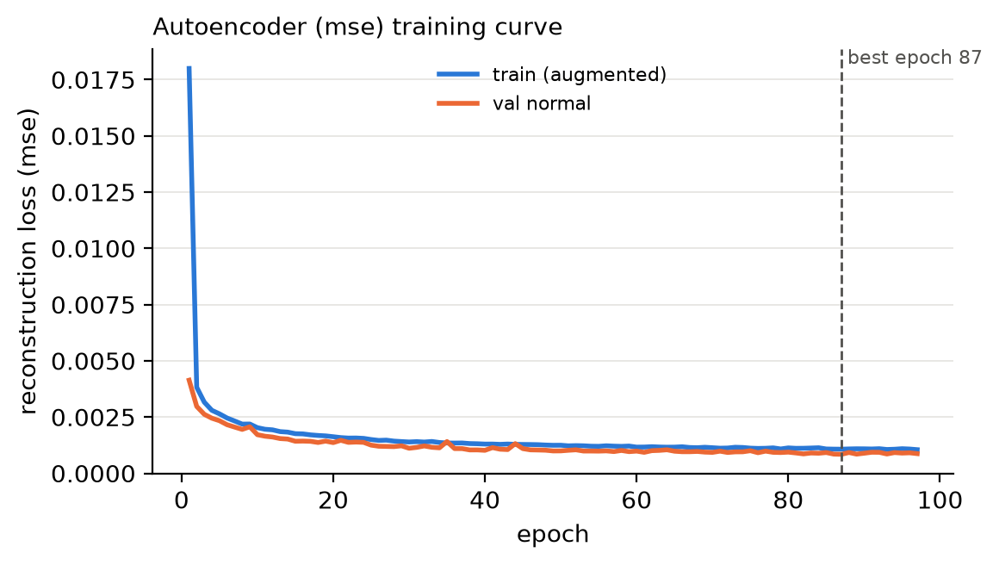

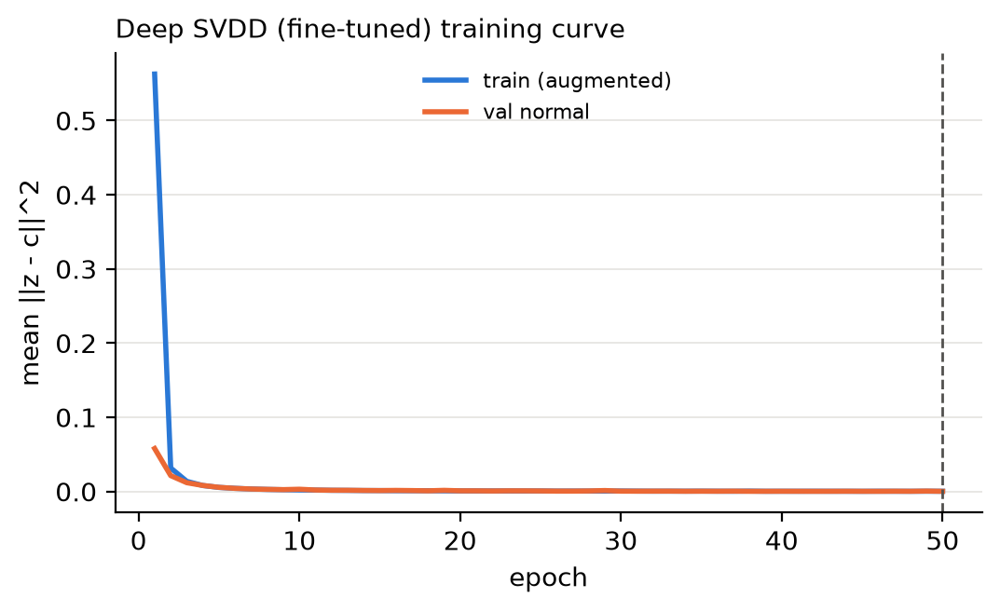

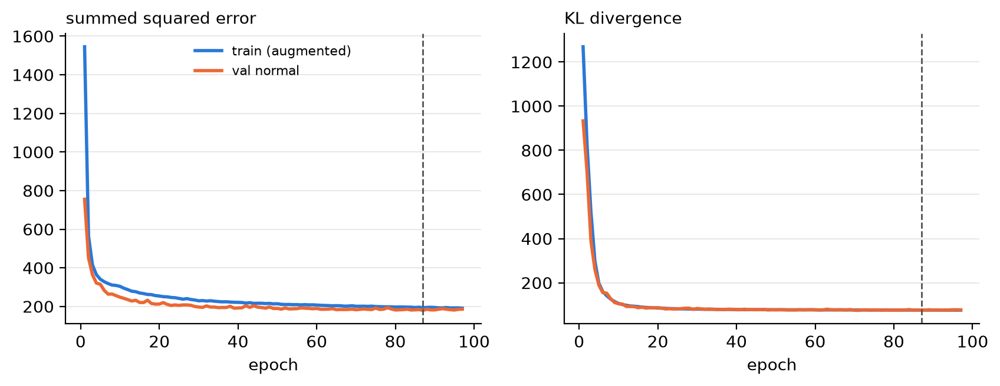

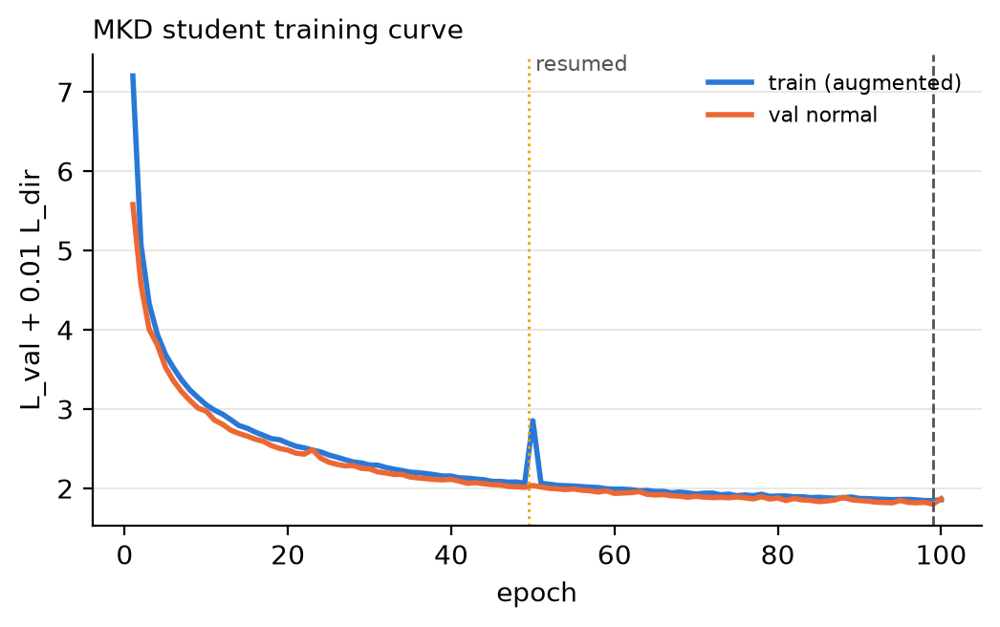

In [9]:
for f in ["ae_loss.png", "svdd_ft_loss.png", "vae_loss.png", "mkd_loss.png"]:
    display(Show(filename=str(ROOT / "outputs/figures" / f), width=620))

## 6. Live scoring with the trained models

One test B-scan per class, scored by all four models; each score is compared with that model's primary threshold
(95th percentile of normal validation scores). Then the anomaly maps.

In [10]:
from nets import ConvAutoencoder, ConvVAE, DeepSVDD, ResNetFeatures, frozen_embedding, VGGStudent, VGGTeacher, mkd_loss, mkd_map
import torch.nn.functional as F

ae = ConvAutoencoder().to(device); ae.load_state_dict(torch.load("models/ae.pt", map_location=device)["state_dict"]); ae.eval()
vae = ConvVAE().to(device); vae.load_state_dict(torch.load("models/vae.pt", map_location=device)["state_dict"]); vae.eval()
res = ResNetFeatures().to(device).eval()
centers = torch.load("models/svdd_centers.pt", map_location=device)
student = VGGStudent().to(device); student.load_state_dict(torch.load("models/mkd.pt", map_location=device)["state_dict"]); student.eval()
teacher = VGGTeacher().to(device)

scores = {k: pd.read_csv(f"outputs/scores/{k}_scores.csv") for k in ["ae", "svdd_frozen", "vae", "mkd"]}
thr = {}
for k, d in scores.items():
    v = d[(d.split == "val") & (d.class_folder == "NORMAL") & (d.bscan_label == "normal")]
    thr[k] = np.percentile(v.score, cfg["threshold_percentile"])

test = scores["svdd_frozen"]; test = test[test.split == "test"]
pick = pd.concat([test[(test.class_folder == "NORMAL") & (test.bscan_label == "normal")].sample(1, random_state=3),
                  test[test.bscan_label == "drusen"].sample(1, random_state=3),
                  test[test.bscan_label == "cnv"].sample(1, random_state=3)]).reset_index(drop=True)

@torch.no_grad()
def live_scores(frame):
    xu = torch.stack([OCTDataset(cfg, frame, norm="unit")[i][0] for i in range(len(frame))]).to(device)
    xi = torch.stack([OCTDataset(cfg, frame, norm="imagenet")[i][0] for i in range(len(frame))]).to(device)
    out = {}
    out["ae"] = ((ae(xu) - xu) ** 2).flatten(1).mean(1)
    out["vae"] = ((vae(xu)[0] - xu) ** 2).flatten(1).mean(1)
    l3, l4 = res(xi)
    out["svdd_frozen"] = ((frozen_embedding(l3, l4) - centers["frozen_c"]) ** 2).sum(1)
    with torch.autocast(device.type, dtype=torch.bfloat16, enabled=device.type == "cuda"):
        fs, ft = student(xi), teacher(xi)
    out["mkd"] = mkd_loss(fs, ft, 0.01)
    return {k: v.float().cpu().numpy() for k, v in out.items()}, xu, xi, (l3, fs, ft)

s_live, xu, xi, feats = live_scores(pick)
rows = []
for i, r in pick.iterrows():
    row = {"B-scan": r.image_path, "label": r.bscan_label}
    for k in ["ae", "svdd_frozen", "vae", "mkd"]:
        row[k] = f"{s_live[k][i]:.4g} " + ("ABNORMAL" if s_live[k][i] >= thr[k] else "normal")
    rows.append(row)
display(pd.DataFrame(rows))
print("thresholds:", {k: round(float(v), 5) for k, v in thr.items()})

,B-scan,label,ae,svdd_frozen,vae,mkd
0,NORMAL/14/OS/015_Normal.jpg,normal,0.001512 ABNORMAL,0.2347 normal,0.004666 normal,2.128 normal
1,DRUSEN/14/OD/022_Drusen.jpg,drusen,0.001116 normal,0.1226 normal,0.00376 normal,1.753 normal
2,CNV/119/019_CNV.tif,cnv,0.001589 ABNORMAL,0.3103 ABNORMAL,0.01454 ABNORMAL,2.469 ABNORMAL


thresholds: {'ae': 0.00139, 'svdd_frozen': 0.25266, 'vae': 0.00599, 'mkd': 2.20099}


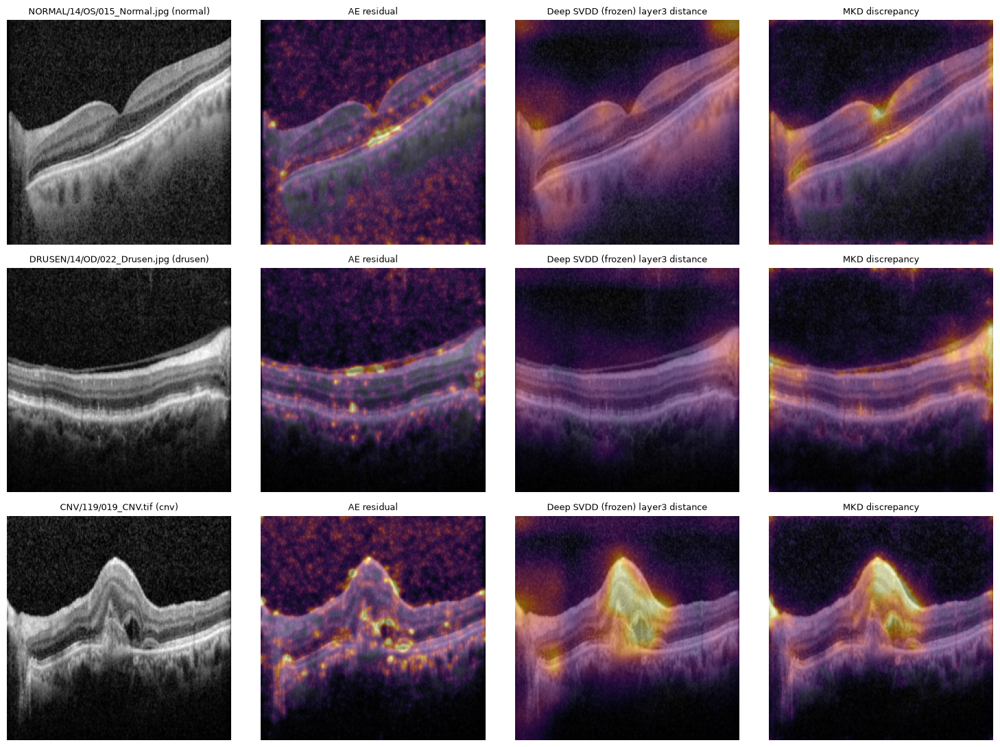

In [11]:
l3, fs, ft = feats
with torch.no_grad():
    ae_map = ((xu - ae(xu)) ** 2)[:, 0].cpu().numpy()
    svdd_map = F.interpolate(((l3 - centers["layer3_mean"][None]) ** 2).sum(1)[:, None], size=xu.shape[-2:],
                             mode="bilinear", align_corners=False)[:, 0].cpu().numpy()
    mkd_m = mkd_map(fs, ft, xu.shape[-2:]).cpu().numpy()
from scipy import ndimage
ae_map = np.stack([ndimage.gaussian_filter(a, 2) for a in ae_map])
fig, ax = plt.subplots(3, 4, figsize=(15, 11))
for i, r in pick.iterrows():
    img = xu[i, 0].cpu().numpy()
    ax[i, 0].imshow(img, cmap="gray"); ax[i, 0].set_title(f"{r.image_path} ({r.bscan_label})")
    for j, (name, mp) in enumerate((("AE residual", ae_map), ("Deep SVDD (frozen) layer3 distance", svdd_map), ("MKD discrepancy", mkd_m)), 1):
        ax[i, j].imshow(img, cmap="gray"); ax[i, j].imshow(mp[i], cmap="inferno", alpha=0.5,
                                                           vmin=np.percentile(mp, 5), vmax=np.percentile(mp, 99.5))
        ax[i, j].set_title(name)
for a in ax.flat: a.axis("off")
plt.tight_layout(); plt.show()

## 7. Validation metrics (mid-review results)

                   method   level    n  roc_auc  pr_auc  accuracy  precision  recall  specificity    f1
           M1 Autoencoder  B-scan 3674    0.636   0.662     0.483      0.731   0.123        0.942 0.210
           M1 Autoencoder patient   98    0.615   0.854     0.194      0.667   0.025        0.944 0.048
    M2 Deep SVDD (frozen)  B-scan 3674    0.650   0.738     0.553      0.863   0.240        0.952 0.375
    M2 Deep SVDD (frozen) patient   98    0.769   0.944     0.582      0.976   0.500        0.944 0.661
M2 Deep SVDD (fine-tuned)  B-scan 3674    0.527   0.603     0.466      0.702   0.080        0.957 0.144
M2 Deep SVDD (fine-tuned) patient   98    0.501   0.842     0.337      0.941   0.200        0.944 0.330



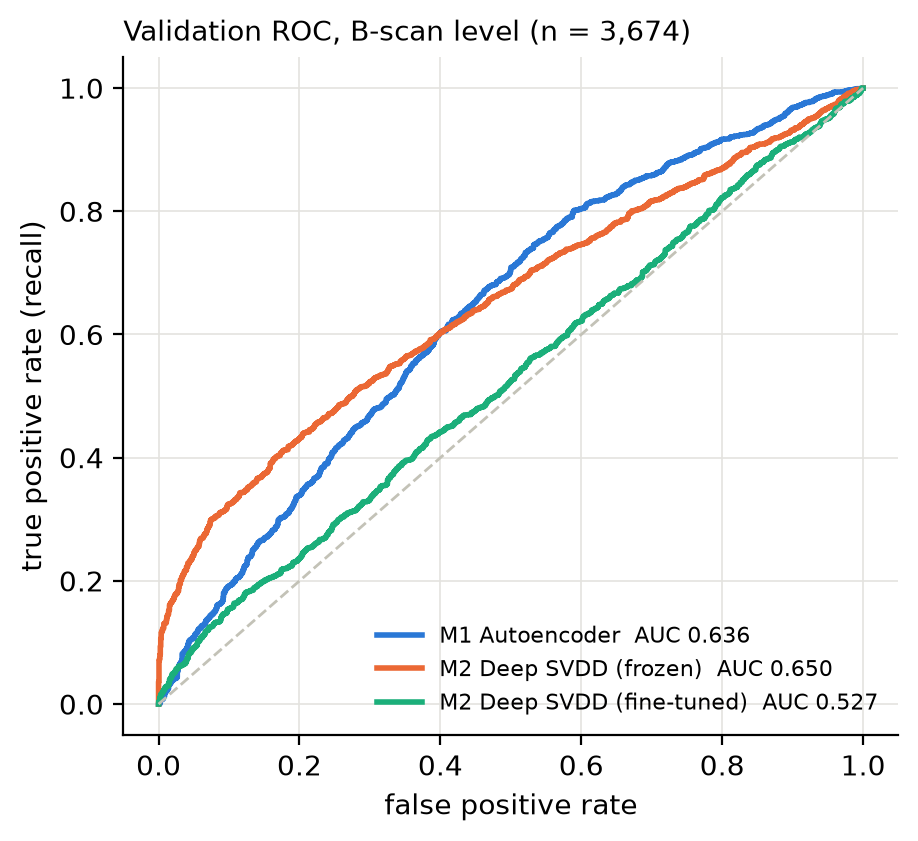

In [12]:
r = subprocess.run([sys.executable, "mid_review_val_summary.py"], capture_output=True, text=True); print(r.stdout)
display(Show(filename=str(ROOT / "outputs/mid_review/val_roc.png"), width=520))

## 8. Test-set comparison (stage 10) and figures (stage 11)

The test set is evaluated once, by `10_compare_models.py`. 95% confidence intervals: 1,000 bootstrap resamples of
test **patients**.

,method,level,roc_auc,roc_auc_ci,pr_auc,pr_auc_baseline,sensitivity_primary,specificity_primary,sens_drusen_primary,sens_cnv_primary
0,ae,bscan,0.570,"[0.516, 0.621]",0.700,0.656,0.106,0.923,0.054,0.188
1,ae,case,0.503,"[0.358, 0.634]",0.911,0.904,0.024,1.000,0.024,0.023
2,svdd_frozen,bscan,0.672,"[0.638, 0.709]",0.815,0.656,0.235,0.970,0.060,0.516
3,svdd_frozen,case,0.814,"[0.751, 0.872]",0.979,0.904,0.465,1.000,0.190,0.733
4,svdd_ft,bscan,0.522,"[0.492, 0.553]",0.673,0.656,0.056,0.952,0.031,0.097
5,svdd_ft,case,0.443,"[0.339, 0.549]",0.914,0.904,0.124,1.000,0.071,0.174
6,vae,bscan,0.674,"[0.628, 0.721]",0.807,0.656,0.259,0.937,0.043,0.606
7,vae,case,0.722,"[0.637, 0.801]",0.965,0.904,0.371,1.000,0.071,0.663
8,mkd,bscan,0.629,"[0.584, 0.679]",0.773,0.656,0.196,0.939,0.034,0.456
9,mkd,case,0.663,"[0.566, 0.757]",0.956,0.904,0.306,1.000,0.060,0.547


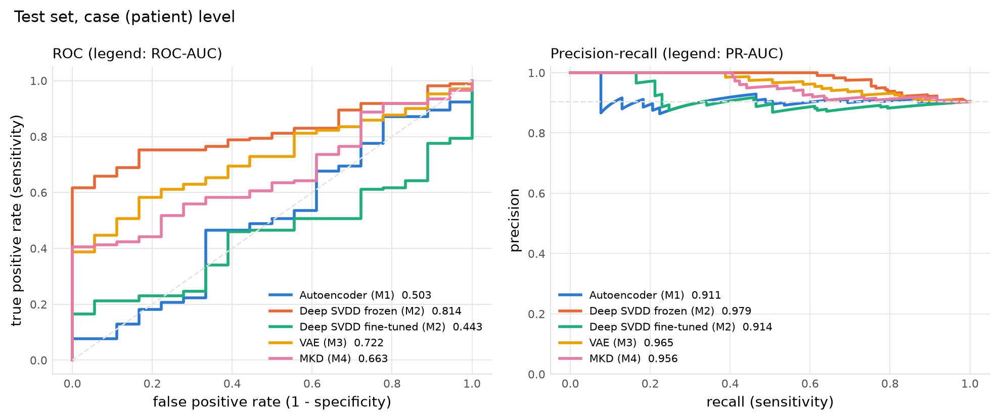

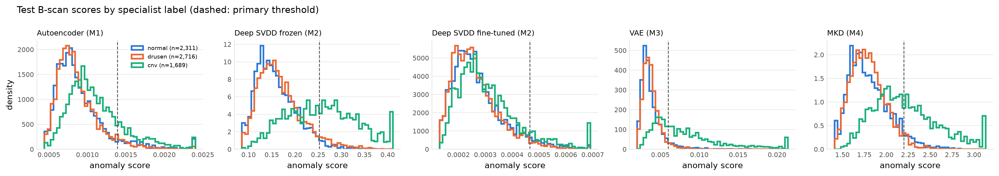

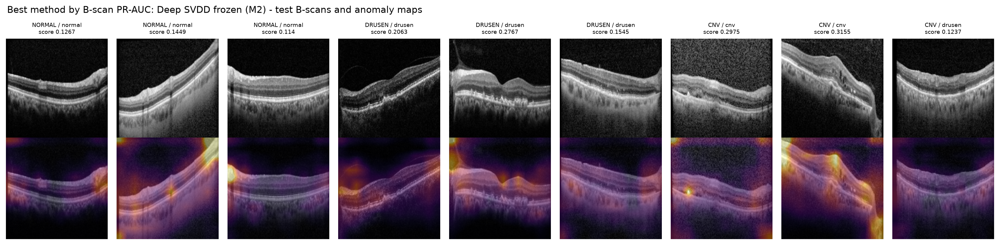

In [13]:
t = pd.read_csv("outputs/metrics/comparison_table.csv")
show = t[["method", "level", "roc_auc", "roc_auc_ci", "pr_auc", "pr_auc_baseline", "sensitivity_primary",
          "specificity_primary", "sens_drusen_primary", "sens_cnv_primary"]].round(3)
display(show)
for f in ["roc_pr_case.png", "score_distributions.png", "best_method_heatmaps.png"]:
    display(Show(filename=str(ROOT / "outputs/figures" / f), width=950))

## 9. Ablations (stage 13): leakage, expanded normal pool, excluded patients

In [14]:
txt = Path("outputs/metrics/ablations.md").read_text(encoding="utf-8")
display(Markdown(txt[txt.index("## Retraining ablations"):]))

## Retraining ablations (13_ablation_retrain.py)

`expanded`: normal-labelled B-scans of the ablation_train DRUSEN/CNV patients added to training. `naive`: image-level random split that ignores patients (leakage); its test set is a different random subset of B-scans, so compare the size of the gain, not individual cells. Thresholds as in the main table (primary, from each setting's own val).

| model | setting | level | roc_auc | pr_auc | sensitivity | specificity |
|---|---|---|---|---|---|---|
| ae | main (patient split, clean pool) | bscan | 0.570 | 0.700 | 0.106 | 0.923 |
| ae | main (patient split, clean pool) | case | 0.503 | 0.911 | 0.024 | 1.000 |
| ae | expanded | bscan | 0.565 | 0.696 | 0.097 | 0.926 |
| ae | expanded | case | 0.489 | 0.908 | 0.029 | 1.000 |
| ae | naive | bscan | 0.595 | 0.701 | 0.052 | 0.957 |
| ae | naive | case | 0.648 | 0.747 | 0.092 | 0.933 |
| svdd_frozen | main (patient split, clean pool) | bscan | 0.672 | 0.815 | 0.235 | 0.970 |
| svdd_frozen | main (patient split, clean pool) | case | 0.814 | 0.979 | 0.465 | 1.000 |
| svdd_frozen | expanded | bscan | 0.672 | 0.815 | 0.232 | 0.972 |
| svdd_frozen | expanded | case | 0.815 | 0.979 | 0.465 | 1.000 |
| svdd_frozen | naive | bscan | 0.669 | 0.804 | 0.273 | 0.938 |
| svdd_frozen | naive | case | 0.877 | 0.931 | 0.556 | 0.942 |
| svdd_ft | main (patient split, clean pool) | bscan | 0.522 | 0.673 | 0.056 | 0.952 |
| svdd_ft | main (patient split, clean pool) | case | 0.443 | 0.914 | 0.124 | 1.000 |
| svdd_ft | expanded | bscan | 0.519 | 0.680 | 0.077 | 0.948 |
| svdd_ft | expanded | case | 0.599 | 0.944 | 0.112 | 1.000 |
| svdd_ft | naive | bscan | 0.581 | 0.723 | 0.169 | 0.918 |
| svdd_ft | naive | case | 0.816 | 0.900 | 0.420 | 0.933 |

## Excluded layout-outlier patients (never in the main table)

Share of their B-scans above the primary B-scan threshold, and their mean percentile among test scores. High values show the layout shortcut the exclusion avoids.

| method | images | flagged_at_primary | mean_score_percentile_vs_test |
|---|---|---|---|
| ae | 208 | 0.000 | 58.698 |
| svdd_frozen | 208 | 0.995 | 96.479 |
| svdd_ft | 208 | 1.000 | 99.907 |
| vae | 208 | 0.971 | 91.105 |
| mkd | 208 | 0.817 | 88.872 |


## 10. Audit (stage 14): end-to-end check of data, models and evaluation

In [15]:
r = subprocess.run([sys.executable, "14_audit.py"], capture_output=True, text=True)
lines = [l for l in r.stdout.splitlines() if l.startswith(("==", "[WARN]", "[FAIL]", "SUMMARY"))]
print("\n".join(lines))

== A. data and splits
== B. score files
== C. saved models reload and reproduce their scores (device cuda)
[WARN] svdd_ft: embedding spread vs centre size (collapse check)  -- per-dim std 1.00e-03, mean |c| 4.45e-01, ratio 0.0023
== D. model behaviour on validation (test not used here)
[FAIL] svdd_ft: val ROC-AUC above chance  -- 0.527
[FAIL] svdd_ft: detects CNV (normal vs CNV ROC-AUC)  -- 0.609
== E. evaluation integrity
== F. repository
[WARN] git working tree clean (everything committed)  -- ?? notebooks/project_walkthrough.ipynb
SUMMARY: 79 PASS, 2 WARN, 2 FAIL


The FAIL lines (if any) concern fine-tuned Deep SVDD: it falls below the audit's "model works" thresholds because
its one-class training collapses the embedding. This is a documented finding (see README), not a bug.